# Assignment 1 - Creating and Manipulating Graphs

Eight employees at a small company were asked to choose 3 movies that they would most enjoy watching for the upcoming company movie night. These choices are stored in the file `assets/Employee_Movie_Choices.txt`.

A second file, `assets/Employee_Relationships.txt`, has data on the relationships between different coworkers. 

The relationship score has value of `-100` (Enemies) to `+100` (Best Friends). A value of zero means the two employees haven't interacted or are indifferent.

Both files are tab delimited.

In [1]:
import networkx as nx
import pandas as pd
import numpy as np


# This is the set of employees
employees = set(['Pablo',
                 'Lee',
                 'Georgia',
                 'Vincent',
                 'Andy',
                 'Frida',
                 'Joan',
                 'Claude'])

# This is the set of movies
movies = set(['The Shawshank Redemption',
              'Forrest Gump',
              'The Matrix',
              'Anaconda',
              'The Social Network',
              'The Godfather',
              'Monty Python and the Holy Grail',
              'Snakes on a Plane',
              'Kung Fu Panda',
              'The Dark Knight',
              'Mean Girls'])


# you can use the following function to plot graphs
# make sure to comment it out before submitting to the autograder
def plot_graph(G, weight_name=None):
    '''
    G: a networkx G
    weight_name: name of the attribute for plotting edge weights (if G is weighted)
    '''
    #%matplotlib notebook
    import matplotlib.pyplot as plt
    
    plt.figure()
    pos = nx.spring_layout(G)
    edges = G.edges()
    weights = None
    
    if weight_name:
        weights = [int(G[u][v][weight_name]) for u,v in edges]
        labels = nx.get_edge_attributes(G,weight_name)
        nx.draw_networkx_edge_labels(G,pos,edge_labels=labels)
        nx.draw_networkx(G, pos, width=weights);
    else:
        nx.draw_networkx(G, pos,);

### Question 1

Using NetworkX, load in the bipartite graph from `assets/Employee_Movie_Choices.txt` and return that graph.

*This function should return a bipartite networkx graph with 19 nodes and 24 edges*

In [16]:
G_df = pd.read_csv('assets/Employee_Movie_Choices.txt', header=0, sep='\t', names=['employee','movie'])
G_df.head()

,employee,movie
0,Andy,Anaconda
1,Andy,Mean Girls
2,Andy,The Matrix
3,Claude,Anaconda
4,Claude,Monty Python and the Holy Grail


In [18]:
# create a network G1 from the df G_df 
G1 = nx.from_pandas_edgelist(G_df, 'employee', 'movie', edge_attr=None)
G1.edges(data=True)

EdgeDataView([('Andy', 'Anaconda', {}), ('Andy', 'Mean Girls', {}), ('Andy', 'The Matrix', {}), ('Anaconda', 'Claude', {}), ('Anaconda', 'Georgia', {}), ('Mean Girls', 'Joan', {}), ('Mean Girls', 'Lee', {}), ('The Matrix', 'Frida', {}), ('The Matrix', 'Pablo', {}), ('Claude', 'Monty Python and the Holy Grail', {}), ('Claude', 'Snakes on a Plane', {}), ('Monty Python and the Holy Grail', 'Georgia', {}), ('Snakes on a Plane', 'Georgia', {}), ('Frida', 'The Shawshank Redemption', {}), ('Frida', 'The Social Network', {}), ('The Shawshank Redemption', 'Pablo', {}), ('The Shawshank Redemption', 'Vincent', {}), ('The Social Network', 'Vincent', {}), ('Joan', 'Forrest Gump', {}), ('Joan', 'Kung Fu Panda', {}), ('Forrest Gump', 'Lee', {}), ('Kung Fu Panda', 'Lee', {}), ('Pablo', 'The Dark Knight', {}), ('Vincent', 'The Godfather', {})])

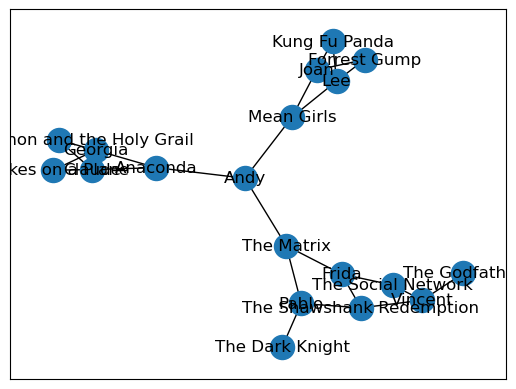

In [19]:
plot_graph(G1, weight_name=None)

In [28]:
def answer_one():

    
    # YOUR CODE HERE
    # read in employee movie choices text file to pandas
    G_df = pd.read_csv('assets/Employee_Movie_Choices.txt', header=0, sep='\t', names=['employee','movie'])
    # create a network G1 from the df G_df 
    G1 = nx.from_pandas_edgelist(G_df, 'employee', 'movie', edge_attr=None)
    plot_graph(G1, weight_name=None)
    
    return G1
    
    # raise NotImplementedError()
 

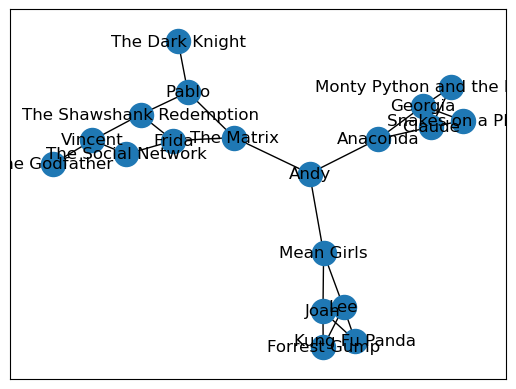

In [29]:
assert type(answer_one()) == nx.Graph , "Your return type should be a Graph object"



### Question 2

Using the graph from the previous question, add nodes attributes named `'type'` where movies have the value `'movie'` and employees have the value `'employee'` and return that graph.

*This function should return a bipartite networkx graph with node attributes `{'type': 'movie'}` or `{'type': 'employee'}`*

In [48]:
import networkx as nx
from networkx.algorithms import bipartite
# add in node attributes (type) -- employee / movie 
G1.add_nodes_from(employees, type='employee', bipartite=0)
G1.add_nodes_from(movies, type='movie', bipartite=1)
G1.nodes(data=True)
# check if graph is bipartite 
bipartite.is_bipartite(G1)

True

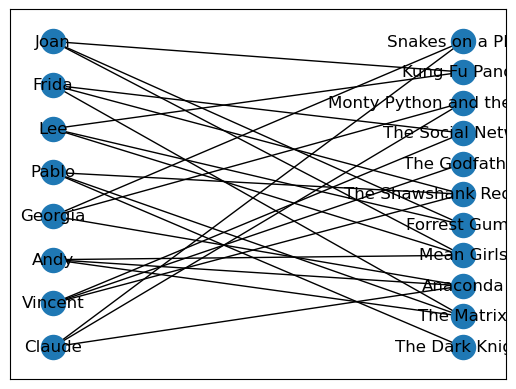

In [53]:
# visualise bipartite graph
nx.draw_networkx(G1, pos=nx.drawing.layout.bipartite_layout(G1, employees))

In [46]:
def answer_two():
    
    import networkx as nx
    from networkx.algorithms import bipartite
    G1.add_nodes_from(employees, type='employee', bipartite=0)
    G1.add_nodes_from(movies, type='movie', bipartite=1)
    # YOUR CODE HERE
    #raise NotImplementedError()
    
    return G1

In [47]:
assert type(answer_two()) == nx.Graph , "Your return type should be a Graph object"


### Question 3

Find a weighted projection of the graph from `answer_two` which tells us how many movies different pairs of employees have in common.

*This function should return a weighted projected graph.*

In [68]:
# find weighted projection graph from answer_two 
P = bipartite.weighted_projected_graph(G1, employees)
P.edges(data=True)

EdgeDataView([('Claude', 'Georgia', {'weight': 3}), ('Claude', 'Andy', {'weight': 1}), ('Vincent', 'Frida', {'weight': 2}), ('Vincent', 'Pablo', {'weight': 1}), ('Andy', 'Joan', {'weight': 1}), ('Andy', 'Georgia', {'weight': 1}), ('Andy', 'Pablo', {'weight': 1}), ('Andy', 'Lee', {'weight': 1}), ('Andy', 'Frida', {'weight': 1}), ('Pablo', 'Frida', {'weight': 2}), ('Lee', 'Joan', {'weight': 3})])

In [60]:
def answer_three():
    # YOUR CODE HERE
    P = bipartite.weighted_projected_graph(G1, employees)
    # raise NotImplementedError()
    return P

EdgeDataView([('Claude', 'Georgia', {'weight': 3}), ('Claude', 'Andy', {'weight': 1}), ('Vincent', 'Frida', {'weight': 2}), ('Vincent', 'Pablo', {'weight': 1}), ('Andy', 'Joan', {'weight': 1}), ('Andy', 'Georgia', {'weight': 1}), ('Andy', 'Pablo', {'weight': 1}), ('Andy', 'Lee', {'weight': 1}), ('Andy', 'Frida', {'weight': 1}), ('Pablo', 'Frida', {'weight': 2}), ('Lee', 'Joan', {'weight': 3})])

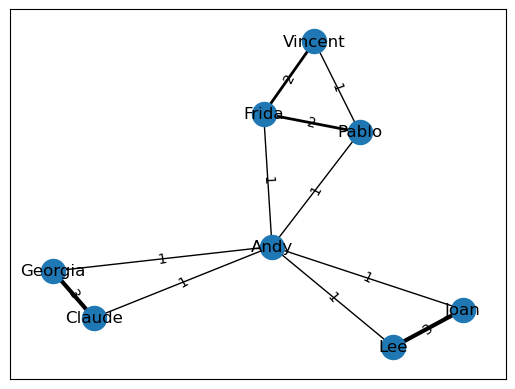

In [61]:
G = answer_three()
plot_graph(G, weight_name="weight")
G.edges(data = True)

In [64]:
assert type(answer_three()) == nx.Graph , "Your return type should be a Graph object"


### Question 4

Suppose you'd like to find out if people that have a high relationship score also like the same types of movies.

Find the pearson correlation between employee relationship scores and the number of movies they have in common. If two employees have no movies in common it should be treated as a 0, not a missing value, and should be included in the correlation calculation.

*This function should return a float.*

In [72]:
# import employees relationship txt data into pd 
rs_df = pd.read_csv('assets/Employee_Relationships.txt', header=0, sep='\t', names=['employee1','employee2','score'])
rs_df.head()

,employee1,employee2,score
0,Andy,Frida,20
1,Andy,Georgia,-10
2,Andy,Joan,30
3,Andy,Lee,-10
4,Andy,Pablo,-10


In [83]:
# convert bipartite projection graph P into pd df 
# Convert to DataFrame
common_movies = pd.DataFrame([(e1, e2, data['weight']) for e1, e2, data in P.edges(data=True)],
                  columns=['employee1', 'employee2', 'score'])
# Sort employee1 and employee2 alphabetically
common_movies[['employee1', 'employee2']] = common_movies.apply(
    lambda row: sorted([row['employee1'], row['employee2']]), axis=1, result_type='expand'
)
common_movies

,employee1,employee2,score
0,Claude,Georgia,3
1,Andy,Claude,1
2,Frida,Vincent,2
3,Pablo,Vincent,1
4,Andy,Joan,1
5,Andy,Georgia,1
6,Andy,Pablo,1
7,Andy,Lee,1
8,Andy,Frida,1
9,Frida,Pablo,2


In [107]:
# merge both pd dataframes across employee1 and employee2 using 
# left inner join for rs_df 
# fill in NaN as 0 
final_df = pd.merge(common_movies, rs_df, on=['employee1', 'employee2'], how='outer')
final_df.columns = ['emp1', 'emp2', 'common_movies', 'rs_score']
final_df = final_df.fillna(0)
# Convert to int
final_df['common_movies'] = final_df['common_movies'].astype(int)
final_df['rs_score'] = final_df['rs_score'].astype(int)
final_df

,emp1,emp2,common_movies,rs_score
0,Claude,Georgia,3,90
1,Andy,Claude,1,0
2,Frida,Vincent,2,60
3,Pablo,Vincent,1,-20
4,Andy,Joan,1,30
5,Andy,Georgia,1,-10
6,Andy,Pablo,1,-10
7,Andy,Lee,1,-10
8,Andy,Frida,1,20
9,Frida,Pablo,2,50


In [108]:
# calculate pearson correlation 
# Pearson correlation
correlation = final_df['common_movies'].corr(final_df['rs_score'], method='pearson')
print("Pearson correlation:", correlation)

Pearson correlation: 0.7883962221733474


In [109]:
def answer_four():
    
    # YOUR CODE HERE
    # import employees relationship txt data into pd 
    rs_df = pd.read_csv('assets/Employee_Relationships.txt', header=0, sep='\t', names=['employee1','employee2','score'])
    
    # convert bipartite projection graph P into pd df 
    common_movies = pd.DataFrame([(e1, e2, data['weight']) for e1, e2, data in P.edges(data=True)],
                      columns=['employee1', 'employee2', 'score'])
    # Sort employee1 and employee2 columns alphabetically
    common_movies[['employee1', 'employee2']] = common_movies.apply(
        lambda row: sorted([row['employee1'], row['employee2']]), axis=1, result_type='expand'
    )
    
    # merge both pd dataframes across employee1 and employee2 using 
    # left inner join for rs_df 
    # if no movies in common then treat as 0 
    final_df = pd.merge(common_movies, rs_df, on=['employee1', 'employee2'], how='outer')
    final_df.columns = ['emp1', 'emp2', 'common_movies', 'rs_score']
    final_df = final_df.fillna(0)
    
    # calculate pearson correlation 
    # Pearson correlation
    correlation = final_df['rs_score'].corr(final_df['common_movies'], method='pearson')
    
    return correlation
    
    # raise NotImplementedError()

In [110]:
ans_four = answer_four()

In [111]:
answer_four()

0.7883962221733473